In [1]:
import os

In [2]:
os.name

'posix'

In [3]:
!pwd

/content


### 데이터 증강

- 다양한 상황에서의 데이터 만들기 
- 같은 1이라는 글자여도, 쓰여있는 위치나 기울어진 정도 등 다양한 경우로 만들기

- RandomCrop
- HorizontalFlip
- ColorJitter


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))])
train = datasets.CIFAR10(root='./data', train=True, download=True, transform=tfm)
loader = DataLoader(train, batch_size=64, shuffle=True)

X,y = next(iter(loader))
print(X.shape, y.shape)

100%|██████████| 170M/170M [00:01<00:00, 92.9MB/s] 


torch.Size([64, 3, 32, 32]) torch.Size([64])


In [5]:
train.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

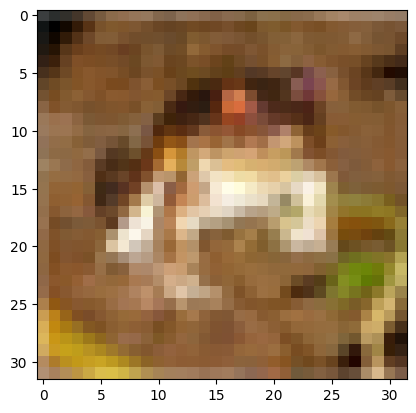

In [13]:
import matplotlib.pyplot as plt
plt.imshow(train.data[0])

In [10]:
aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

In [19]:
tfm_basic = transforms.Compose([
    transforms.ToTensor(),
    
])
tfm_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

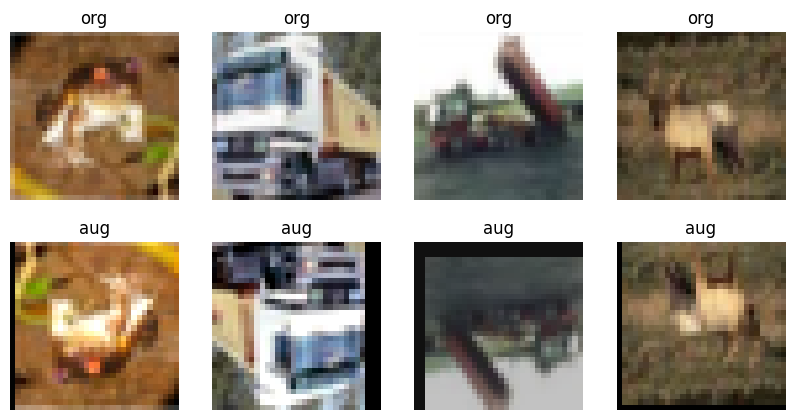

In [18]:
train = datasets.CIFAR10(root='./data', train=True, download=True)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i in range(4):
    
    img = train[i][0]
    axes[0, i].imshow(img)
    axes[0, i].set_title('org')
    axes[0, i].axis('off')

    aug_img = tfm_aug(img).permute(1, 2, 0).numpy()
    axes[1, i].imshow(aug_img) 
    axes[1, i].set_title('aug')
    axes[1, i].axis('off')
    
plt.show()

In [ ]:
tfm_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),(0.5, 0.5, 0.5))
])

train = datasets.CIFAR10(root='./data', train=True, download=True)
loader = DataLoader(train, batch_size=64, shuffle=True)

In [20]:
# 모델 정의
class CNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # 첫 번째 레이어(64,3,32,32) -> (64,32,16,16)
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(3,32,kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 두 번째 레이어(64,32,16,16) -> (64,64,8,8)
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(32,64,kernel_size=3, stride=1, padding=1),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # MLP 완전 연결 레이어(64,64,8,8) -> (64,10)
        self.fc = torch.nn.Linear(64*8*8, 10, bias=True)

        # 가중치(w) 초기화
        # torch.nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1) # flatten, reshape과 동일
        out = self.fc(out)
        return out
    

model = CNN()

In [22]:
torch.manual_seed(9)

# 학습률
learning_rate = 0.001
# 학습횟수
training_epochs = 15
# 배치 사이즈
batch_size = 64

# 손실함수(오차 계산) -> mnist는 분류하는 문제이므로 CrossEntropyLoss 사용
criterion = torch.nn.CrossEntropyLoss()
# 경사하강법 알고리즘 -> Adam 사용
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

